# DocClassify — Exploration & Evaluation Notebook
**IE University · AI: Statistical Learning and Prediction**

This notebook covers:
1. Dataset overview & class distributions
2. Text length analysis
3. Top TF-IDF features per class
4. Confusion matrix & classification report
5. Live prediction examples with invoice extraction
6. Error analysis

## 0 · Category Justification

The system classifies documents into four categories. Each was chosen because it is common in real business and academic workflows, and because the four classes are **linguistically and structurally distinct** enough for a classical ML model to separate reliably.

---

### Invoice
**Why chosen:** Invoices are the primary target of the extraction pipeline. They are the most structured document type — every invoice, regardless of format, contains a predictable set of fields (number, dates, parties, amount).

**Key distinguishing features:**
- Presence of monetary amounts with currency symbols (, , , , , )
- Explicit field labelling: , , , 
- Tabular line-item layout
- Billing vocabulary: *payable*, *subtotal*, *VAT*, *net*, *remittance*

---

### Email
**Why chosen:** Emails are the most ubiquitous business document. Misclassifying an email as an invoice would be a costly error in any document processing pipeline.

**Key distinguishing features:**
- Structured header block: , , , 
- Conversational register and informal closings (*Best*, *Thanks*, *Regards*)
- Domain references () and hyperlinks
- No monetary or legal structure

---

### Scientific Report
**Why chosen:** Academic papers have a rigid structure and highly specialised vocabulary that makes them easy to separate from all other classes.

**Key distinguishing features:**
- Section headers: *Abstract*, *Introduction*, *Methodology*, *Results*, *Conclusion*
- Mathematical notation and statistical language (, , )
- Citation style: 
- Formal, impersonal academic register

---

### Letter
**Why chosen:** Formal letters (legal, contractual, governmental) are a common document type that shares surface features with emails (salutation, body, closing) — making them a genuinely challenging class.

**Key distinguishing features:**
- Physical address block at the top
- Formal salutations: *Dear Sir/Madam*, *To Whom It May Concern*
- Formal closings: *Yours sincerely*, *Yours faithfully*
- Legal language: *hereby*, *pursuant to*, *aforementioned*, *obligations*
- Signature lines

---

### Why these four form a good classification problem

| Class | Register | Structure | Monetary | Legal |
|---|---|---|---|---|
| Invoice | Formal/neutral | High | Yes | Partial |
| Email | Informal/neutral | Low | Rare | No |
| Scientific Report | Formal/academic | High | No | No |
| Letter | Formal | Medium | Rare | Often |

The combination of **register**, **structural rigidity**, **vocabulary**, and **layout cues** gives the TF-IDF + LinearSVC model enough signal to separate the classes with near-perfect accuracy.


In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
from scipy.sparse import hstack
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score
)

# ── style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

LABEL_COLORS = {
    "invoice":           "#2563eb",
    "email":             "#16a34a",
    "scientific_report": "#9333ea",
    "letter":            "#d97706",
}
LABELS = ["invoice", "email", "scientific_report", "letter"]
print("OK imports OK")

OK imports OK


## 1 · Dataset Overview

Train : 19,001 rows
Test  : 3,125 rows

                   Train  Test  Train %  Test %
label                                          
invoice             4001   125     21.1     4.0
email               5000  1000     26.3    32.0
scientific_report   5000  1000     26.3    32.0
letter              5000  1000     26.3    32.0


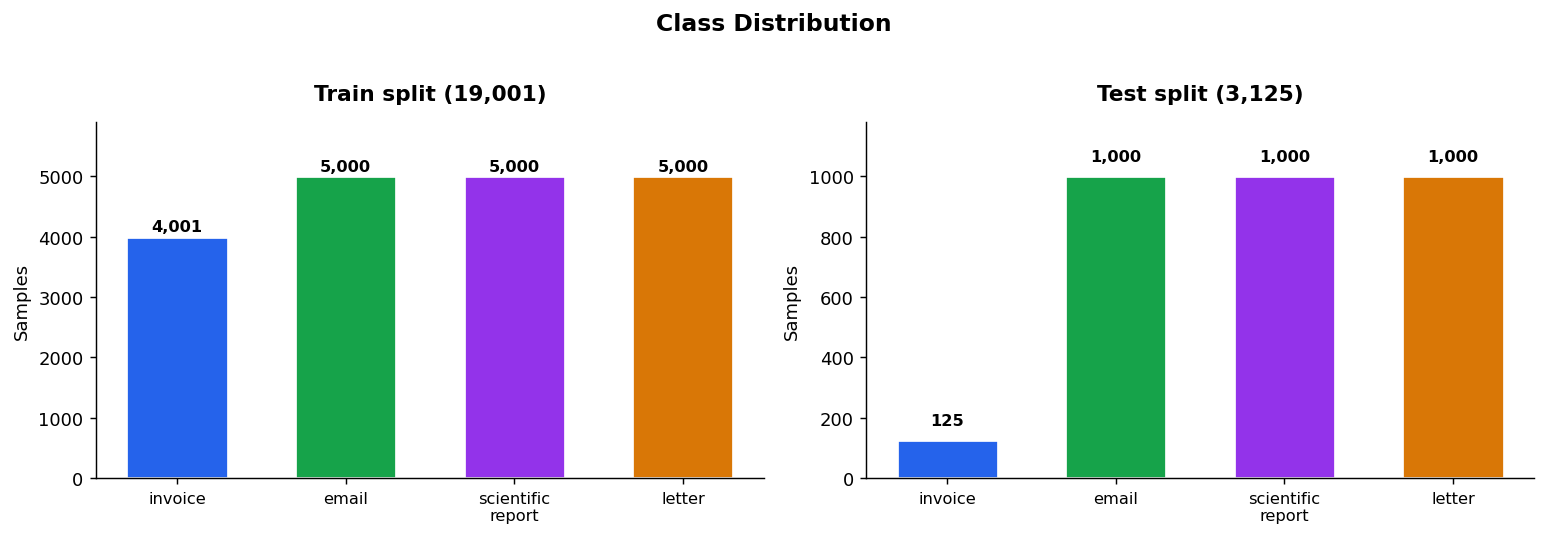

In [2]:
train = pd.read_csv(ROOT / "data/processed/train.csv")
test  = pd.read_csv(ROOT / "data/processed/test.csv")

print(f"Train : {len(train):,} rows")
print(f"Test  : {len(test):,} rows")
print()

tr_counts = train["label"].value_counts().reindex(LABELS)
te_counts = test["label"].value_counts().reindex(LABELS)

summary = pd.DataFrame({
    "Train": tr_counts,
    "Test":  te_counts,
    "Train %": (tr_counts / tr_counts.sum() * 100).round(1),
    "Test %":  (te_counts / te_counts.sum()  * 100).round(1),
})
print(summary.to_string())

# ── bar chart ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (df, title) in zip(axes, [(train, "Train split (19,001)"), (test, "Test split (3,125)")]):
    counts = df["label"].value_counts().reindex(LABELS)
    colors = [LABEL_COLORS[l] for l in LABELS]
    bars   = ax.bar(LABELS, counts.values, color=colors, width=0.6, edgecolor="white", linewidth=1.5)
    ax.set_title(title, fontweight="bold", pad=12)
    ax.set_ylabel("Samples")
    ax.set_ylim(0, max(counts.values) * 1.18)
    ax.set_xticklabels([l.replace("_", "\n") for l in LABELS], fontsize=9)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                f"{val:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.suptitle("Class Distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 2 · Text Length Analysis

                   Chars mean  Chars median  Chars min  Chars max  Words mean  Words median  Words min  Words max
label                                                                                                            
email                    1109           768         81       3000         232           163         10       1321
invoice                   374           312        278        578          44            41         40         60
letter                    386           311        101       1500          61            49         14        258
scientific_report        3000          3000       3000       3000         468           452        194       1248


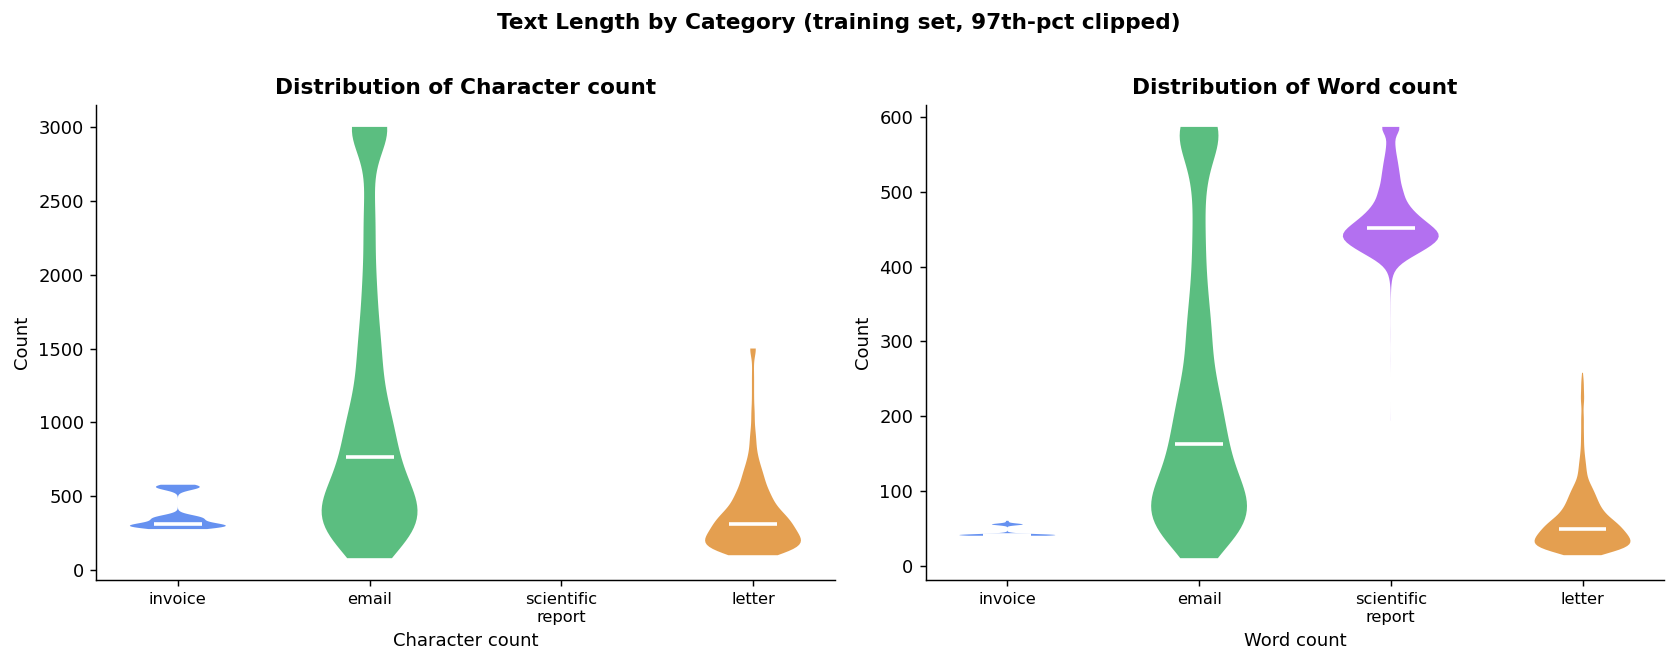

In [3]:
train["char_len"] = train["text"].str.len()
train["word_len"] = train["text"].str.split().str.len()

# ── stats table ────────────────────────────────────────────────────────────
stats = (train.groupby("label")[["char_len","word_len"]]
         .agg(["mean","median","min","max"])
         .round(0).astype(int))
stats.columns = ["Chars mean","Chars median","Chars min","Chars max",
                 "Words mean","Words median","Words min","Words max"]
print(stats.to_string())

# ── violin plots ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, xlabel in zip(
    axes,
    ["char_len", "word_len"],
    ["Character count", "Word count"],
):
    data   = [train[train["label"] == l][col].clip(upper=train[col].quantile(0.97)).values
               for l in LABELS]
    colors = [LABEL_COLORS[l] for l in LABELS]

    parts = ax.violinplot(data, positions=range(len(LABELS)),
                          showmedians=True, showextrema=False)
    for body, color in zip(parts["bodies"], colors):
        body.set_facecolor(color)
        body.set_alpha(0.7)
    parts["cmedians"].set_color("white")
    parts["cmedians"].set_linewidth(2)

    ax.set_xticks(range(len(LABELS)))
    ax.set_xticklabels([l.replace("_", "\n") for l in LABELS], fontsize=9)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.set_title(f"Distribution of {xlabel}", fontweight="bold")

plt.suptitle("Text Length by Category (training set, 97th-pct clipped)",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 3 · Top TF-IDF Features per Class

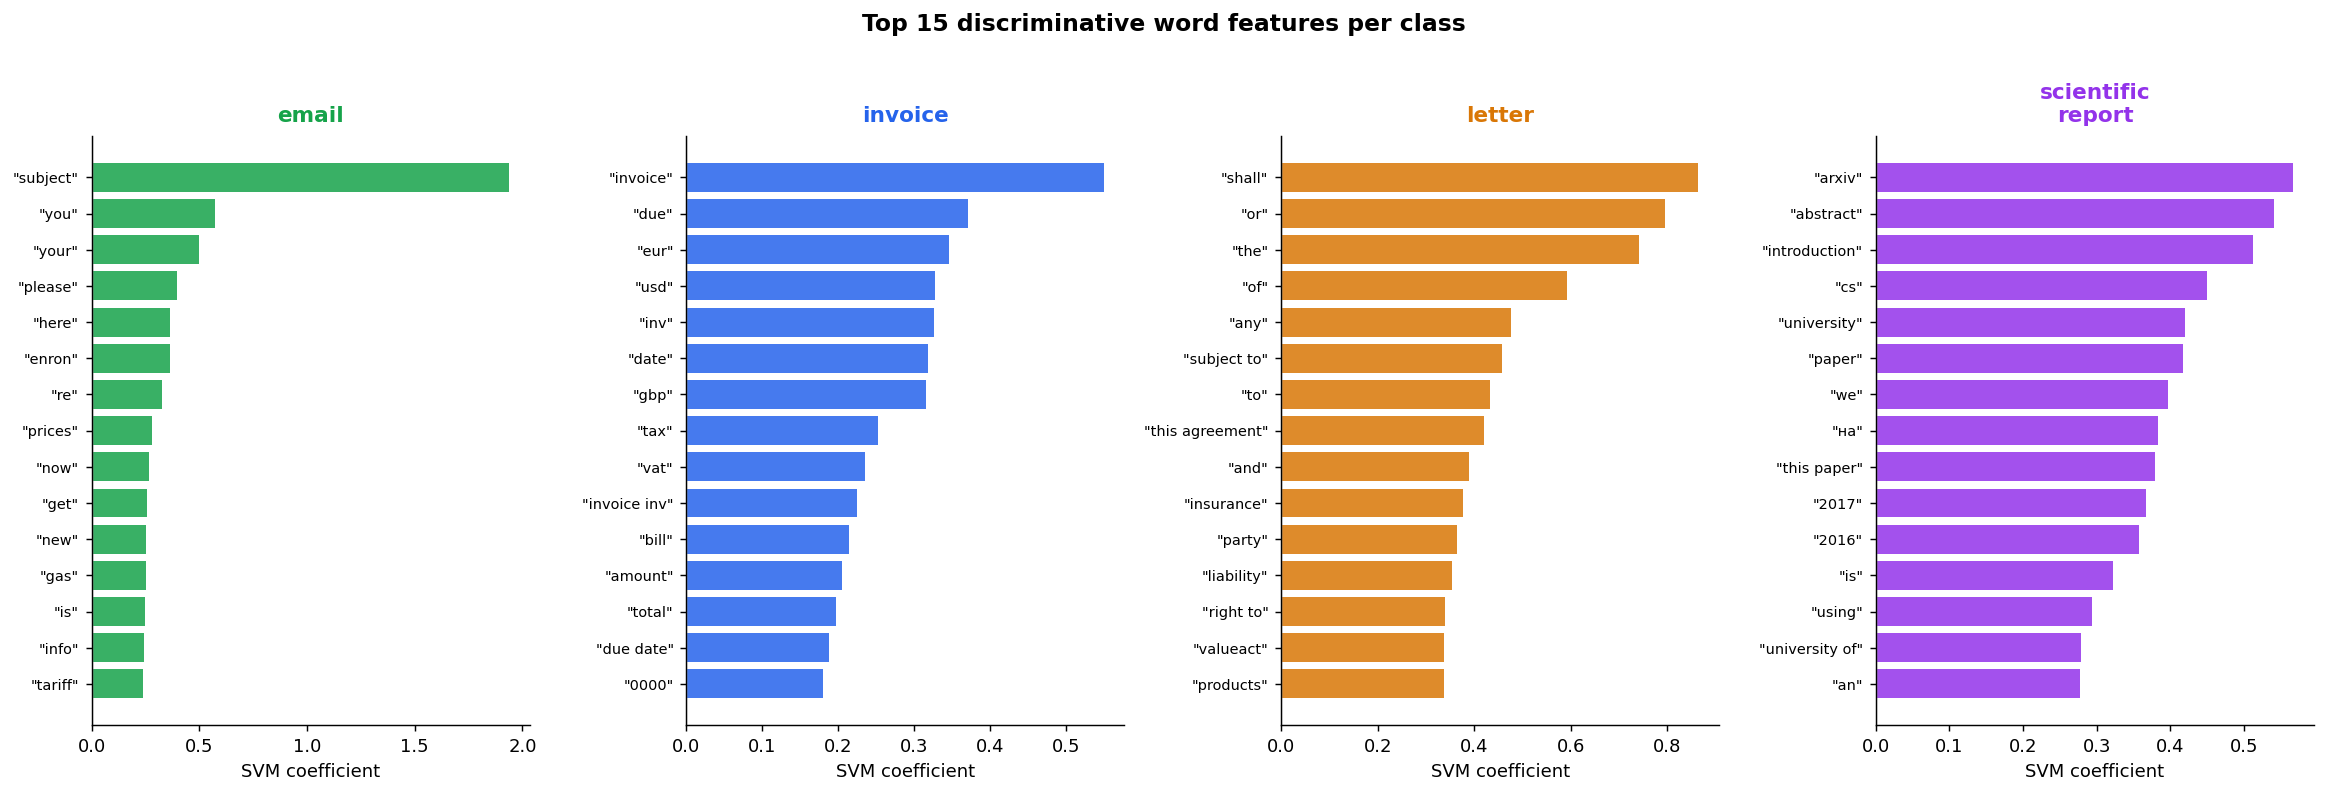

In [4]:
word_vec = joblib.load(ROOT / "models/word_vectorizer.joblib")
clf      = joblib.load(ROOT / "models/classifier.joblib")

n_top          = 15
feature_names  = word_vec.get_feature_names_out()
n_word_feats   = len(feature_names)   # 80 000 — coef_ first block is word features

fig, axes = plt.subplots(1, 4, figsize=(18, 6))

for ax, label in zip(axes, clf.classes_):
    idx   = list(clf.classes_).index(label)
    # Only consider the word-feature slice of coef_
    coefs = clf.coef_[idx][:n_word_feats]

    top_idx    = np.argsort(coefs)[-n_top:][::-1]
    top_feats  = feature_names[top_idx]
    top_scores = coefs[top_idx]

    color = LABEL_COLORS.get(label, "#555")
    ax.barh(range(n_top), top_scores[::-1], color=color, alpha=0.85)
    ax.set_yticks(range(n_top))
    ax.set_yticklabels([f'"{f}"' for f in top_feats[::-1]], fontsize=8)
    ax.set_title(label.replace("_", "\n"), fontweight="bold", color=color, pad=8)
    ax.set_xlabel("SVM coefficient")
    ax.axvline(0, color="#ccc", linewidth=0.8)

plt.suptitle("Top 15 discriminative word features per class",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 4 · Confusion Matrix & Classification Report

Test Accuracy : 99.9680%
Errors        : 1 / 3125

                   precision    recall  f1-score   support

            email       1.00      1.00      1.00      1000
          invoice       1.00      1.00      1.00       125
           letter       1.00      1.00      1.00      1000
scientific_report       1.00      1.00      1.00      1000

         accuracy                           1.00      3125
        macro avg       1.00      1.00      1.00      3125
     weighted avg       1.00      1.00      1.00      3125



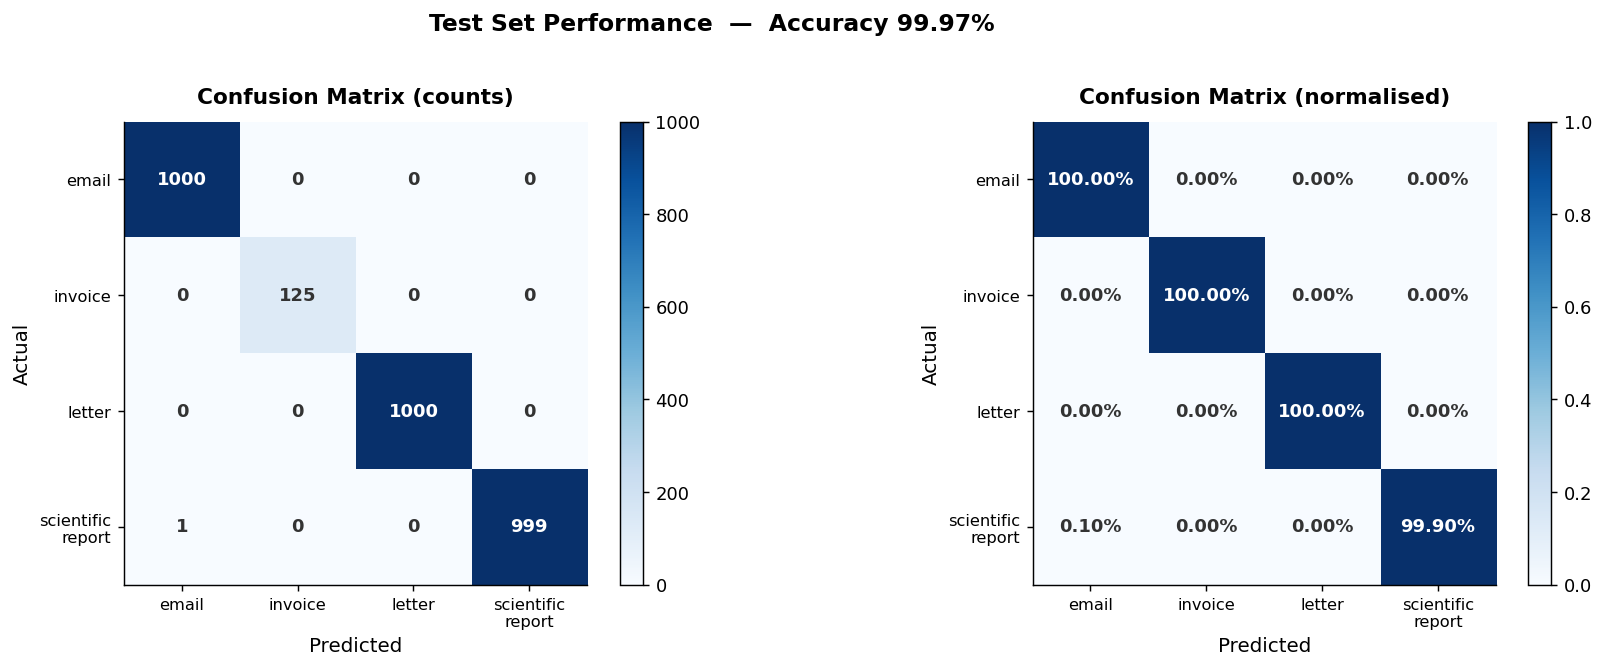

In [5]:
char_vec = joblib.load(ROOT / "models/char_vectorizer.joblib")

X_test = test["text"].fillna("").tolist()
y_test = test["label"].tolist()

X_feat = hstack([word_vec.transform(X_test), char_vec.transform(X_test)])
y_pred = clf.predict(X_feat)

acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy : {acc*100:.4f}%")
print(f"Errors        : {(np.array(y_test) != np.array(y_pred)).sum()} / {len(y_test)}")
print()
print(classification_report(y_test, y_pred, target_names=sorted(set(y_test))))

# ── confusion matrix heatmap ───────────────────────────────────────────────
ordered = sorted(set(y_test))
cm      = confusion_matrix(y_test, y_pred, labels=ordered)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, title, fmt in zip(
    axes,
    [cm, cm_norm],
    ["Confusion Matrix (counts)", "Confusion Matrix (normalised)"],
    [".0f", ".2%"],
):
    im = ax.imshow(data, cmap="Blues", vmin=0, vmax=data.max())
    ax.set_xticks(range(len(ordered)))
    ax.set_yticks(range(len(ordered)))
    ax.set_xticklabels([l.replace("_", "\n") for l in ordered], fontsize=9)
    ax.set_yticklabels([l.replace("_", "\n") for l in ordered], fontsize=9)
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual",    fontsize=11)
    ax.set_title(title, fontweight="bold", pad=10)
    for i in range(len(ordered)):
        for j in range(len(ordered)):
            val  = data[i, j]
            text = format(val, fmt)
            ax.text(j, i, text, ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="white" if val > data.max()*0.5 else "#333")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"Test Set Performance  —  Accuracy {acc*100:.2f}%",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 5 · Live Prediction Examples with Invoice Extraction

In [6]:
from predict import predict

DEMO_DOCS = {
    "invoice": """INVOICE
Invoice Number: INV-7842
Invoice Date:   2024-05-20
Due Date:       2024-06-20

From: Nexus Analytics Ltd
To:   Fatima Al-Hassan

Cloud Hosting (monthly)   1   USD  899.00
Tax (20%)                     USD  179.80
──────────────────────────────────────────
TOTAL                         USD 1,078.80

Payment terms: Net 30 days
IBAN: GB29 NWBK 6016 1331 9268 19""",

    "email": """From: morgan.lee@startup.io
To: all@startup.io
Date: Fri, 12 Apr 2024 08:15:00
Subject: Reminder: Docs freeze at 5pm today

Hey everyone,

Quick reminder that the documentation freeze for the v2.1 release is
at 5pm today. Please make sure all your PRs are merged and docs updated.

Thanks,
Morgan""",

    "scientific_report": """Title: Transformer Models for Time-Series Anomaly Detection

Abstract
This work introduces TemporalBERT, a transformer-based architecture
adapted for multivariate time-series anomaly detection. We pre-train
on 50M unlabelled sensor readings and fine-tune on three industrial
benchmarks. Our method achieves AUROC of 0.964, surpassing the prior
state-of-the-art by 3.2 points with 40% fewer parameters.

1. Introduction
Anomaly detection in time-series data is critical for predictive
maintenance and fraud detection. Classical approaches such as ARIMA
and isolation forests struggle with high-dimensional correlated signals.

2. Results
Table 2 compares TemporalBERT against baselines on the SMD, SMAP,
and MSL datasets. Statistical significance is confirmed at p<0.01.""",

    "letter": """TENANCY AGREEMENT LETTER

Date: 01 March 2024
Landlord: Zenith Properties Ltd
Tenant:   Kenji Tanaka

Property: Flat 9, 88 Park Avenue, Madrid, Spain

This letter confirms the tenancy agreement for the above property
commencing 01 April 2024 for a fixed term of 12 months.

Monthly Rent: EUR 1,450
Deposit:      EUR 2,900

Both parties agree to the terms and conditions set out in the full
tenancy agreement dated 01 March 2024.

Signed: _________________________    Date: ___________
        Landlord / Agent

Signed: _________________________    Date: ___________
        Tenant""",
}

for true_label, text in DEMO_DOCS.items():
    result  = predict(text)
    pred    = result["label"]
    correct = "True" if pred == true_label else "False"
    print(f"{correct}  Expected: {true_label:<20} → Predicted: {pred}")
    if pred == "invoice":
        for k, v in result["extraction"].items():
            s = "OK" if v else "MISSING"
            print(f"     {s} {k:<22} {v or 'not found'}")
    print()

True  Expected: invoice              → Predicted: invoice
     OK invoice_number         INV-7842
     OK invoice_date           2024-05-20
     OK due_date               2024-06-20
     OK issuer_name            Nexus Analytics Ltd
     OK recipient_name         Fatima Al-Hassan
     OK total_amount           1078.80

True  Expected: email                → Predicted: email

True  Expected: scientific_report    → Predicted: scientific_report

True  Expected: letter               → Predicted: letter



## 6 · Error Analysis

In [7]:
errors = test[np.array(y_test) != np.array(y_pred)].copy()
errors["predicted"] = [y_pred[i] for i in errors.index]

print(f"Total errors: {len(errors)}\n")
print("Error breakdown (true → predicted):")
print(errors.groupby(["label","predicted"]).size().to_string())
print()

if len(errors) > 0:
    for _, row in errors.iterrows():
        print(f"─── True: {row['label']}  →  Predicted: {row['predicted']} ───")
        # Show first 400 chars
        preview = row["text"][:400].replace("\n", " ")
        print(f"  {preview}…")
        print()
else:
    print("No errors — perfect test set performance.")

Total errors: 1

Error breakdown (true → predicted):
label              predicted
scientific_report  email        1

─── True: scientific_report  →  Predicted: email ───
  МАТЕМАТИЧЕСКИЙ И ПРОГРАММНЫЙ АППАРАТ АВТОМАТИЗИРОВАННОГО ПРОЕКТИРОВАНИЯ АКСОНОМЕТРИЧЕСКИХ СХЕМ ТРУБОПРОВОДНЫХ СИСТЕМ В.В. Мигунов Рассматривается применение модульной технологии разработки проблемно-ориентированных расширений систем автоматизированного проектирования [1] к задаче автоматизации подготовки аксонометрических схем трубопроводных систем (АСТС). В [2] выявлено единство состава схем для …



## 7 · Invoice Extraction Benchmark

Run the regex extractor across all test invoices and measure field coverage.

Invoice test samples: 125

Field extraction coverage on test invoices:
  invoice_number         100.0%  ████████████████████
  invoice_date           100.0%  ████████████████████
  due_date               100.0%  ████████████████████
  issuer_name            100.0%  ████████████████████
  recipient_name         100.0%  ████████████████████
  total_amount           100.0%  ████████████████████


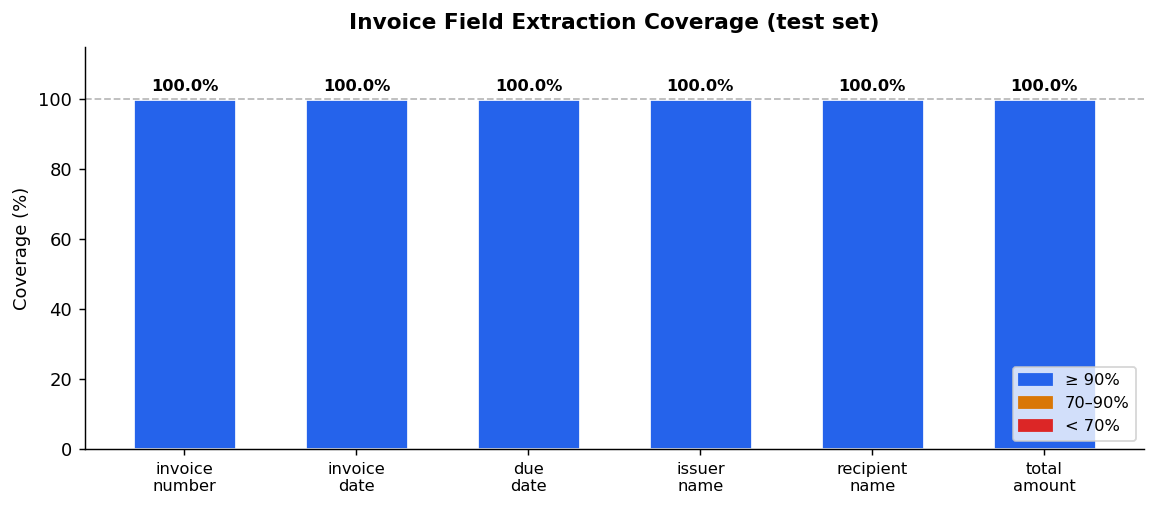

In [8]:
from extract import extract_invoice_fields

inv_test = test[test["label"] == "invoice"]["text"].tolist()
print(f"Invoice test samples: {len(inv_test)}")

fields = ["invoice_number","invoice_date","due_date","issuer_name","recipient_name","total_amount"]
results_list = [extract_invoice_fields(t) for t in inv_test]
coverage_df  = pd.DataFrame(results_list)

# Coverage = % of samples where the field was successfully extracted
coverage = (coverage_df.notna() & (coverage_df != "")).mean() * 100

print("\nField extraction coverage on test invoices:")
for field, pct in coverage.items():
    bar = "█" * int(pct / 5)
    print(f"  {field:<22} {pct:5.1f}%  {bar}")

# ── bar chart ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
colors  = ["#2563eb" if v >= 90 else "#d97706" if v >= 70 else "#dc2626"
           for v in coverage.values]
bars    = ax.bar(coverage.index, coverage.values, color=colors, width=0.6,
                 edgecolor="white", linewidth=1.5)
ax.set_ylim(0, 115)
ax.set_ylabel("Coverage (%)")
ax.set_title("Invoice Field Extraction Coverage (test set)", fontweight="bold", pad=10)
ax.set_xticklabels([f.replace("_", "\n") for f in coverage.index], fontsize=9)
ax.axhline(100, color="#bbb", linestyle="--", linewidth=1)
for bar, val in zip(bars, coverage.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")

legend_patches = [
    mpatches.Patch(color="#2563eb", label="≥ 90%"),
    mpatches.Patch(color="#d97706", label="70–90%"),
    mpatches.Patch(color="#dc2626", label="< 70%"),
]
ax.legend(handles=legend_patches, loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()